Import data and perform Data analysis

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import statsmodels.api as sm
import seaborn as sns
path=r"C:\Users\ladom\Desktop\ML\Data\housing.csv"

df=pd.read_csv(path)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [2]:
print(df.columns)
print(df.info())

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [3]:
df["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [4]:
# check for missing values 
missing_values=df.isnull().sum() 

# Calculate percentage of missing data in each column 
missing_percentage=(missing_values/len(df))*100 

# Display the missing data statisrics 
print("Missing values for each column:\n",missing_values)
print("\nPercentage of missing data:\n", missing_percentage)


Missing values for each column:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Percentage of missing data:
 longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64


In [5]:
# Remove raws with missing values 
df_cleaned=df.dropna()

# Make sure raws with missing values has been removed 
print("\nMissing values in each column afer removal: ")
print(df_cleaned.isnull().sum())


Missing values in each column afer removal: 
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


Data Exploration and Visualization

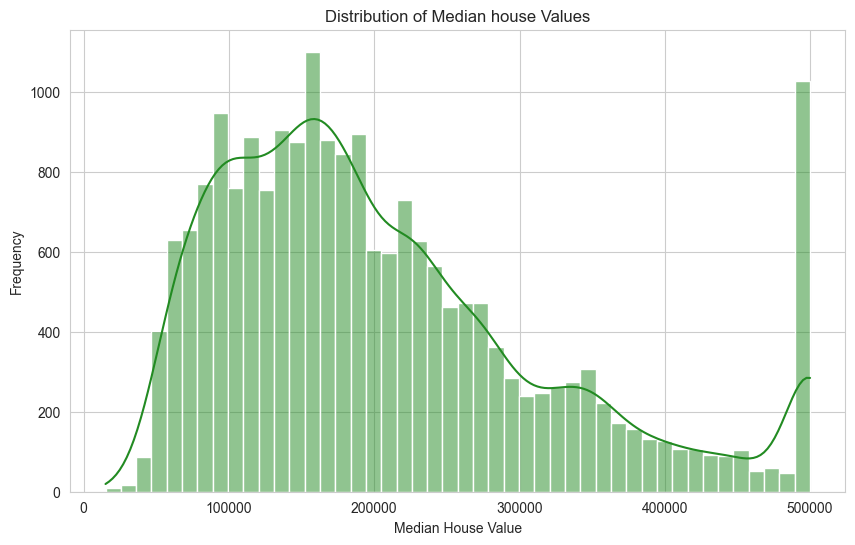

In [10]:
sns.set_style(style="whitegrid")
plt.figure(figsize=(10,6))
sns.histplot(df_cleaned["median_house_value"], color="forestgreen", kde=True) 
plt.title("Distribution of Median house Values")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

Using InterQualtile Range to Remove outliers 

In [11]:
Q1=df_cleaned["median_house_value"].quantile(0.25)
Q3=df_cleaned["median_house_value"].quantile(0.75) 
IQR=Q3-Q1

# Define the bounds of outliers 
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR 

# remove outliers 
df_no_outliers_1=df_cleaned[(df_cleaned["median_house_value"]>=lower_bound) & (df_cleaned["median_house_value"]<=upper_bound)]

# Check the shape of the data before and after removal of outliers 
print("Original data shape:", df_cleaned.shape)
print("New data shape without outliers: ", df_no_outliers_1.shape)

Original data shape: (20433, 10)
New data shape without outliers:  (19369, 10)


BoxPlot for  outlier Detection

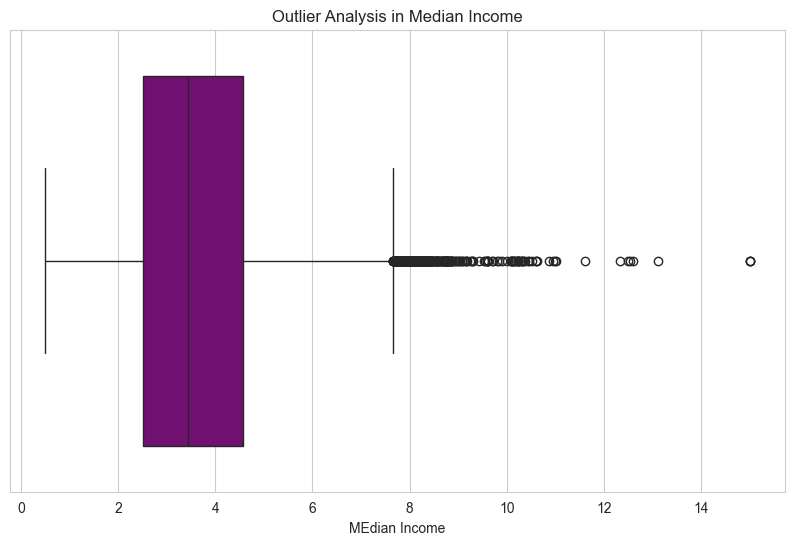

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df_no_outliers_1["median_income"], color="purple")
plt.title("Outlier Analysis in Median Income")
plt.xlabel("MEdian Income")
plt.show()

In [15]:
# Calculate Q1 and Q3 
Q1=df_no_outliers_1["median_income"].quantile(0.25)
Q3=df_no_outliers_1["median_income"].quantile(0.75)
IQR=Q3-Q1 
print(Q1,Q3, IQR)
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
# Remove outliers 
df_no_outliers_2=df_no_outliers_1[(df_no_outliers_1["median_income"]>=lower_bound) & (df_no_outliers_1["median_income"]<=upper_bound)]

# Check the shape of data before and after the removal of outliers 
print("Original Data shape:", df_no_outliers_1.shape)
print("New data shape without outliers: ", df_no_outliers_2.shape)

2.5223 4.5724 2.0501
Original Data shape: (19369, 10)
New data shape without outliers:  (19026, 10)


In [16]:
df=df_no_outliers_2

Correlation HeatMap 

In [21]:
from seaborn import cm


plt.figure(figsize=(10,6))
sns.heatmap(df[:-1].corr(), annot=True, cmap="Greens")
plt.title("Correlation Heatmap of Housing Data")
plt.show()

ValueError: could not convert string to float: 'NEAR BAY'

<Figure size 1000x600 with 0 Axes>